In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("../Data/raw/german_credit_data.csv")

print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print(df.columns.to_list)
print(df.sample(3, random_state=42))
print(f"Duplicate rows: {df.duplicated().sum()}")


Rows : 1000
Columns : 21
<bound method IndexOpsMixin.tolist of Index(['status_account', 'month_duration', 'credit_history', 'purpose',
       'credit_amount', 'status_savings', 'years_employment',
       'payment_to_income_ratio', 'status_and_sex', 'secondary_obligor',
       'residence_since', 'collateral', 'age', 'other_installment_plans',
       'housing', 'n_credits', 'job', 'n_guarantors', 'telephone',
       'is_foreign_worker', 'target'],
      dtype='str')>
    status_account  month_duration                            credit_history  \
521         < 0 DM              18  existing credits paid back duly till now   
737         < 0 DM              18  existing credits paid back duly till now   
740         < 0 DM              24   all credits at this bank paid back duly   

              purpose  credit_amount   status_savings years_employment  \
521  radio/television           3190         < 100 DM   1 to < 4 years   
737         car (new)           4380  100 to < 500 DM   1 to 

In [52]:
print(df.dtypes)
print(df['target'].value_counts())


status_account               str
month_duration             int64
credit_history               str
purpose                      str
credit_amount              int64
status_savings               str
years_employment             str
payment_to_income_ratio    int64
status_and_sex               str
secondary_obligor            str
residence_since            int64
collateral                   str
age                        int64
other_installment_plans      str
housing                      str
n_credits                  int64
job                          str
n_guarantors               int64
telephone                    str
is_foreign_worker            str
target                       str
dtype: object
target
good    700
bad     300
Name: count, dtype: int64


In [53]:
categorical_col = df.select_dtypes(include=['object']).columns.to_list()

categorical_col = [c for c in categorical_col if c !='target']

print(categorical_col)

for col in categorical_col:
    print(f"\t--{col}--")
    print(f"Unique Counts:{df[col].nunique()}")
    print(f"{df[col].value_counts()}")
    print(f"-"*20)


['status_account', 'credit_history', 'purpose', 'status_savings', 'years_employment', 'status_and_sex', 'secondary_obligor', 'collateral', 'other_installment_plans', 'housing', 'job', 'telephone', 'is_foreign_worker']
	--status_account--
Unique Counts:4
status_account
no checking account    394
< 0 DM                 274
0 to < 200 DM          269
>= 200 DM               63
Name: count, dtype: int64
--------------------
	--credit_history--
Unique Counts:5
credit_history
existing credits paid back duly till now                       530
critical account/ other credits existing (not at this bank)    293
delay in paying off in the past                                 88
all credits at this bank paid back duly                         49
no credits taken/ all credits paid back duly                    40
Name: count, dtype: int64
--------------------
	--purpose--
Unique Counts:10
purpose
radio/television       280
car (new)              234
furniture/equipment    181
car (used)             1

/tmp/ipykernel_4216/2924610886.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = df.select_dtypes(include=['object']).columns.to_list()


In [54]:
print("Numerical Columns Analysis")

numerical_col = ['month_duration', 'credit_amount', 'payment_to_income_ratio', 
                  'residence_since', 'age', 'n_credits', 'n_guarantors']

print("--Descriptive Stats--")
#print(df[numerical_col].describe())

print("\t--Low Cardinality Ordinal Features--")
for col in ['payment_to_income_ratio', 'residence_since', 'n_credits', 'n_guarantors']:
    print(f"\t--{col}--")
    print(df[col].value_counts().sort_index())

Numerical Columns Analysis
--Descriptive Stats--
	--Low Cardinality Ordinal Features--
	--payment_to_income_ratio--
payment_to_income_ratio
1    136
2    231
3    157
4    476
Name: count, dtype: int64
	--residence_since--
residence_since
1    130
2    308
3    149
4    413
Name: count, dtype: int64
	--n_credits--
n_credits
1    633
2    333
3     28
4      6
Name: count, dtype: int64
	--n_guarantors--
n_guarantors
1    845
2    155
Name: count, dtype: int64


In [55]:
df_clean = df.copy()

for col in categorical_col:
    df_clean[col] = df_clean[col].str.strip()

    df_clean[col] = df_clean[col].str.replace(r'\s+',' ',regex=True)

    df_clean[col] = df_clean[col].str.replace(r's*/\s*','/',regex=True)

print(f"status_savings unique: {df_clean['status_savings'].unique()}")

status_savings unique: <StringArray>
['unknown/no savings account',                   '< 100 DM',
           '500 to < 1000 DM',                 '>= 1000 DM',
            '100 to < 500 DM']
Length: 5, dtype: str


In [56]:
telephone_map = {
    'yes, registered under the customers name': 'yes',
    'none': 'no'
}

df_clean['telephone'] = df_clean['telephone'].map(telephone_map)

print(df_clean['telephone'].value_counts())

telephone
no     596
yes    404
Name: count, dtype: int64


In [57]:
print(df['status_and_sex'].value_counts())
df_clean[['sex','marital_status']] = df_clean['status_and_sex'].str.split(' : ',expand=True)

df_clean = df_clean.drop('status_and_sex',axis=1)

print(f"\nSex distribution")
print(f"{df_clean['sex'].value_counts()}")
print("\nMarital status distribution:")
print(df_clean['marital_status'].value_counts())

status_and_sex
male : single                          548
female : divorced/separated/married    310
male : married/widowed                  92
male : divorced/separated               50
Name: count, dtype: int64

Sex distribution
sex
male      690
female    310
Name: count, dtype: int64

Marital status distribution:
marital_status
single                        548
divorced/separated/married    310
married/widowed                92
divorced/separated             50
Name: count, dtype: int64


In [58]:
pir_order = [1,2,3,4]
df_clean['payment_to_income_ratio'] = pd.Categorical(df_clean['payment_to_income_ratio'],categories=pir_order,ordered=True)

res_order = [1,2,3,4]
df_clean['residence_since'] = pd.Categorical(df_clean['residence_since'],categories=res_order,ordered=True)

print(df_clean[['payment_to_income_ratio','residence_since']].dtypes)

payment_to_income_ratio    category
residence_since            category
dtype: object


In [59]:
none_col = []

for col in df_clean.columns:
    if "none" in df_clean[col].values:
        none_col.append(col)

print(f"Columns containing 'none': {none_col}")


Columns containing 'none': ['secondary_obligor', 'collateral', 'other_installment_plans']


In [60]:
status_account_map = {
    'no checking account': 'no_checking',
    '< 0 DM': 'negative',
    '0 to < 200 DM': 'low_balance',
    '>= 200 DM': 'high_balance'
}

credit_history_map = {
    'existing credits paid back duly till now': 'current_paid',
    'critical account/other credits existing (not at this bank)': 'critical_other',
    'delay in paying off in the past': 'delayed_past',
    'all credits at this bank paid back duly': 'all_paid_here',
    'no credits taken/all credits paid back duly': 'no_credits'
}

status_savings_map = {
    'unknown/no savings account': 'unknown',
    '< 100 DM': 'very_low',
    '100 to < 500 DM': 'low',
    '500 to < 1000 DM': 'medium',
    '>= 1000 DM': 'high'
}

years_employment_map = {
    'unemployed': 'unemployed',
    '< 1 year': 'Junior',
    '1 to < 4 years': 'Mid-Level',
    '4 to < 7 years': 'Senior',
    '>= 7 years': 'Expert'
}

job_map = {
    'unemployed/unskilled - non-resident': 'unemployed',
    'unskilled - resident': 'unskilled',
    'skilled employee/official': 'skilled',
    'management/self-employed/highly qualified employee': 'management'
}
purpose_map = {
    'radio/television': 'radio_tv',
    'car (new)': 'car_new',
    'car (used)': 'car_used',
    'furniture/equipment': 'furniture',
    'domestic appliances': 'appliances',
    'business': 'business',
    'education': 'education',
    'repairs': 'repairs',
    'others': 'others',
    'retraining': 'retraining'
}
df_clean['purpose'] = df_clean['purpose'].map(purpose_map)
df_clean['status_account'] = df_clean['status_account'].map(status_account_map)
df_clean['credit_history'] = df_clean['credit_history'].map(credit_history_map)
df_clean['status_savings'] = df_clean['status_savings'].map(status_savings_map)
df_clean['years_employment'] = df_clean['years_employment'].map(years_employment_map)
df_clean['job'] = df_clean['job'].map(job_map)

print(df_clean[['status_account', 'credit_history', 'status_savings', 'years_employment', 'job']].head())


  status_account  credit_history status_savings years_employment        job
0       negative  critical_other        unknown           Expert    skilled
1    low_balance    current_paid       very_low        Mid-Level    skilled
2    no_checking  critical_other       very_low           Senior  unskilled
3       negative    current_paid       very_low           Senior    skilled
4       negative    delayed_past       very_low        Mid-Level    skilled


In [61]:
df_clean['target'] = df_clean['target'].map({"good":1,"bad":0})
print(df_clean['target'].value_counts())

target
1    700
0    300
Name: count, dtype: int64


In [62]:
missing = df_clean.isnull().sum()
print("Missing Values Per Columns")
print(missing[missing > 0] if missing.sum()>0 else "No missing")

Missing Values Per Columns
No missing


In [63]:
df_clean.head(5)

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,secondary_obligor,residence_since,...,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target,sex,marital_status
0,negative,6,critical_other,radio_tv,1169,unknown,Expert,4,none,4,...,none,own,2,skilled,1,yes,yes,1,male,single
1,low_balance,48,current_paid,radio_tv,5951,very_low,Mid-Level,2,none,2,...,none,own,1,skilled,1,no,yes,0,female,divorced/separated/married
2,no_checking,12,critical_other,education,2096,very_low,Senior,2,none,3,...,none,own,1,unskilled,2,no,yes,1,male,single
3,negative,42,current_paid,furniture,7882,very_low,Senior,2,guarantor,4,...,none,for free,1,skilled,2,no,yes,1,male,single
4,negative,24,delayed_past,car_new,4870,very_low,Mid-Level,3,none,4,...,none,for free,2,skilled,2,no,yes,0,male,single


/tmp/ipykernel_4216/155431349.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[0,0].scatter(df_clean['month_duration'],df_clean['credit_amount'],cmap='red')


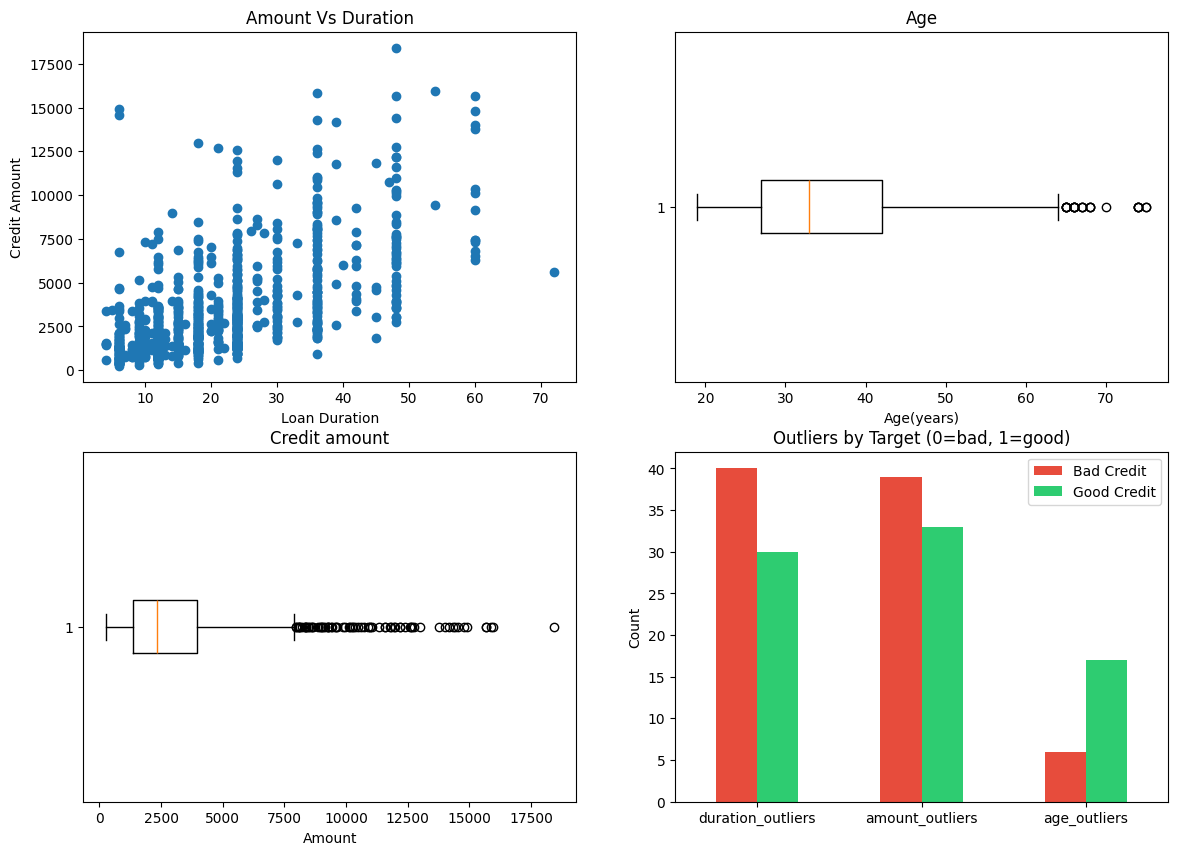

In [64]:
fig , axes = plt.subplots(ncols=2,nrows=2,figsize=(14,10))

axes[0,0].scatter(df_clean['month_duration'],df_clean['credit_amount'],cmap='red')
axes[0,0].set_title("Amount Vs Duration")
axes[0,0].set_ylabel("Credit Amount")
axes[0,0].set_xlabel("Loan Duration")

axes[0,1].boxplot(df_clean['age'],vert = False)
axes[0,1].set_title("Age")
axes[0,1].set_xlabel("Age(years)")

axes[1,0].boxplot(df_clean['credit_amount'],vert = False)
axes[1,0].set_title("Credit amount")
axes[1,0].set_xlabel("Amount")

outlier_df = df_clean.copy()
outlier_df['duration_outlier'] = df['month_duration'] > 42
outlier_df['amount_outlier'] = df['credit_amount'] > 7882
outlier_df['age_outlier'] = df['age'] > 64.5

outlier_summary = pd.DataFrame({
    'duration_outliers': outlier_df.groupby('target')['duration_outlier'].sum(),
    'amount_outliers': outlier_df.groupby('target')['amount_outlier'].sum(),
    'age_outliers': outlier_df.groupby('target')['age_outlier'].sum()
})
outlier_summary.T.plot(kind='bar', ax=axes[1, 1], color=['#e74c3c', '#2ecc71'])
axes[1, 1].set_title('Outliers by Target (0=bad, 1=good)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(['Bad Credit', 'Good Credit'])
axes[1, 1].tick_params(axis='x', rotation=0)


In [65]:
#print(df_clean['marital_status'].value_counts())

marital_target = pd.crosstab(df_clean['marital_status'],df['target'],normalize='index')

marital_target.columns = ["bad_rate","good_rate"]

print(marital_target.round(3))

from scipy.stats import chi2_contingency

ct = pd.crosstab(df_clean['marital_status'],df_clean['target'])

chi2,p_val,dof,expec =  chi2_contingency(ct)
print(f"Chi-square statistics : {chi2:.4f}")
print(f"p value : {p_val:.4f}")
print(f"significant at 0.05 : {"yes" if p_val<0.05 else "no"}")

sex_target = pd.crosstab([df_clean['sex'],df_clean['marital_status']],df['target'],normalize='index')

sex_target.columns = ["bad_rate","good_rate"]
print(sex_target.round(3))


                            bad_rate  good_rate
marital_status                                 
divorced/separated             0.400      0.600
divorced/separated/married     0.352      0.648
married/widowed                0.272      0.728
single                         0.266      0.734
Chi-square statistics : 9.6052
p value : 0.0222
significant at 0.05 : yes
                                   bad_rate  good_rate
sex    marital_status                                 
female divorced/separated/married     0.352      0.648
male   divorced/separated             0.400      0.600
       married/widowed                0.272      0.728
       single                         0.266      0.734


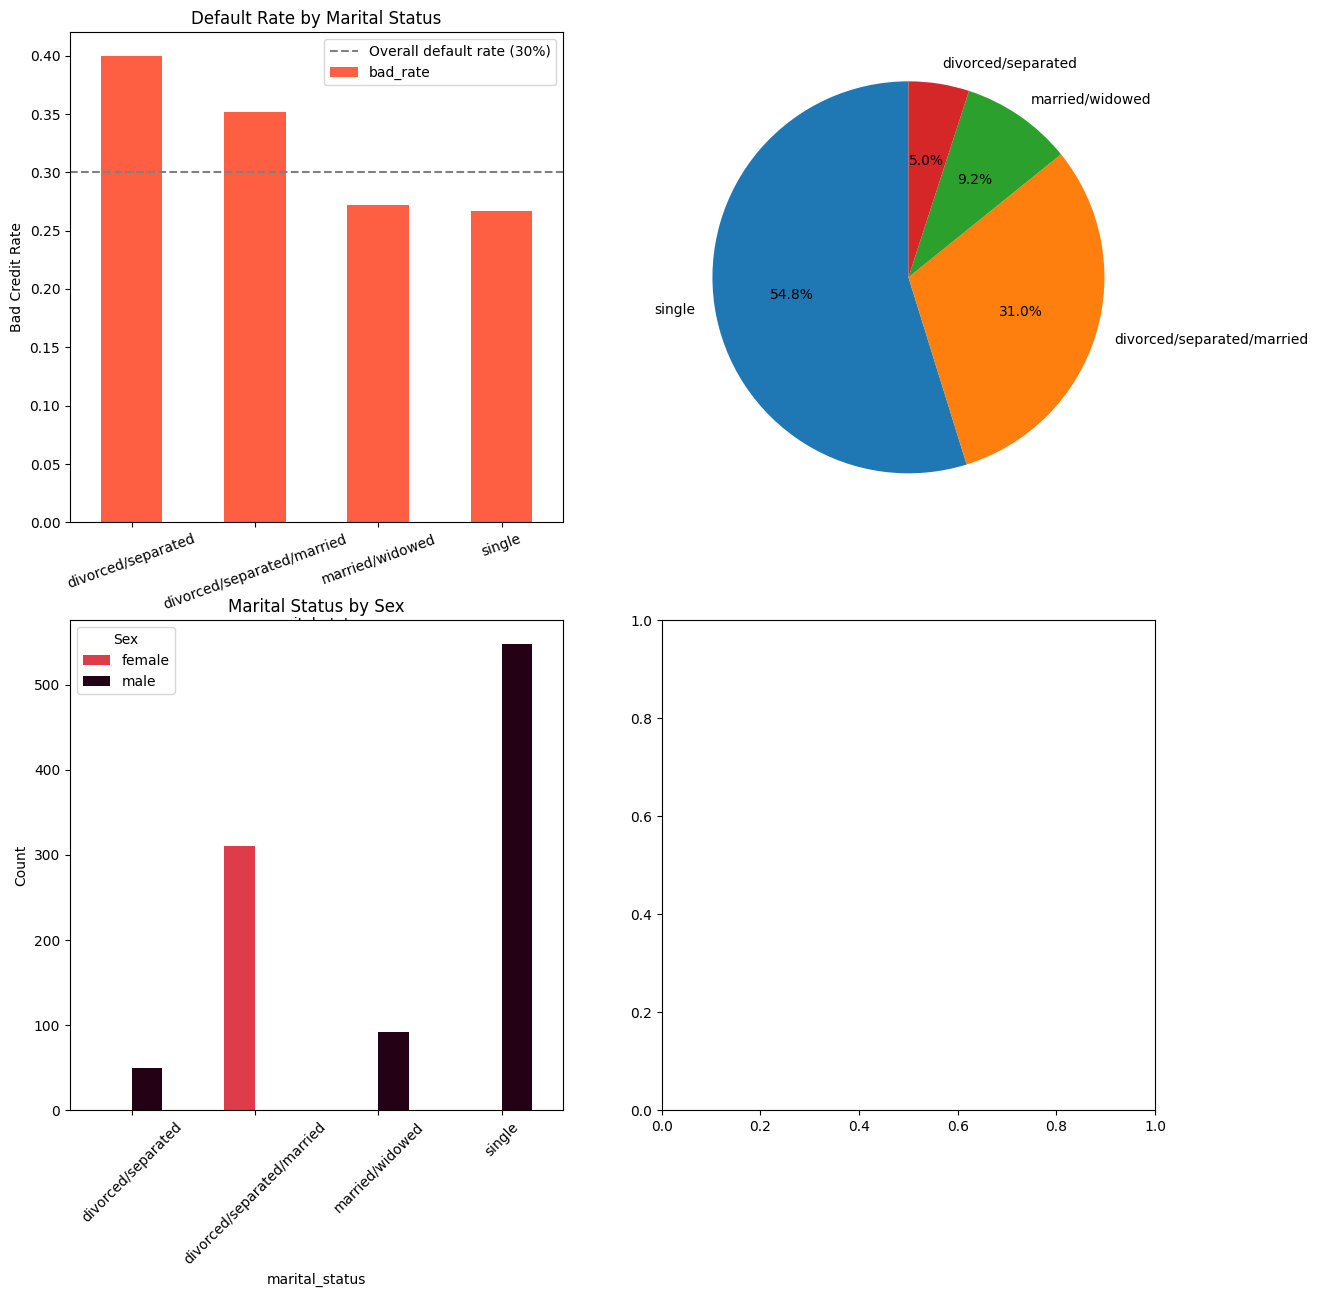

In [73]:
fig2 , axes2 = plt.subplots(2,2,figsize=(14,14))

marital_bad = marital_target.iloc[:,0]
marital_good = marital_target.iloc[:,1]

#print(marital_bad)
#print(marital_good)

marital_bad.plot(kind='bar',ax=axes2[0,0],color="#FE5E41")
axes2[0, 0].set_title('Default Rate by Marital Status')
axes2[0, 0].set_ylabel('Bad Credit Rate')
axes2[0, 0].tick_params(axis='x', rotation=20)
axes2[0, 0].axhline(y=0.3, color='gray', linestyle='--', label='Overall default rate (30%)')
axes2[0, 0].legend()

marital_count = df_clean['marital_status'].value_counts()
axes2[0,1].pie(marital_count,labels=marital_count.index,autopct='%1.1f%%',startangle=90)

marital_sex = pd.crosstab(df_clean['marital_status'],df_clean['sex'])
marital_sex.plot(kind='bar',ax=axes2[1,0],color=['#DE3C4B','#240115'])
axes2[1, 0].set_title('Marital Status by Sex')
axes2[1, 0].set_ylabel('Count')
axes2[1, 0].tick_params(axis='x', rotation=45)
axes2[1, 0].legend(title='Sex')

/tmp/ipykernel_4216/3691007534.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='target_label', y='credit_amount', ax=axes3[1, 1],
/tmp/ipykernel_4216/3691007534.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='target_label', y='age', ax=axes3[1, 2],


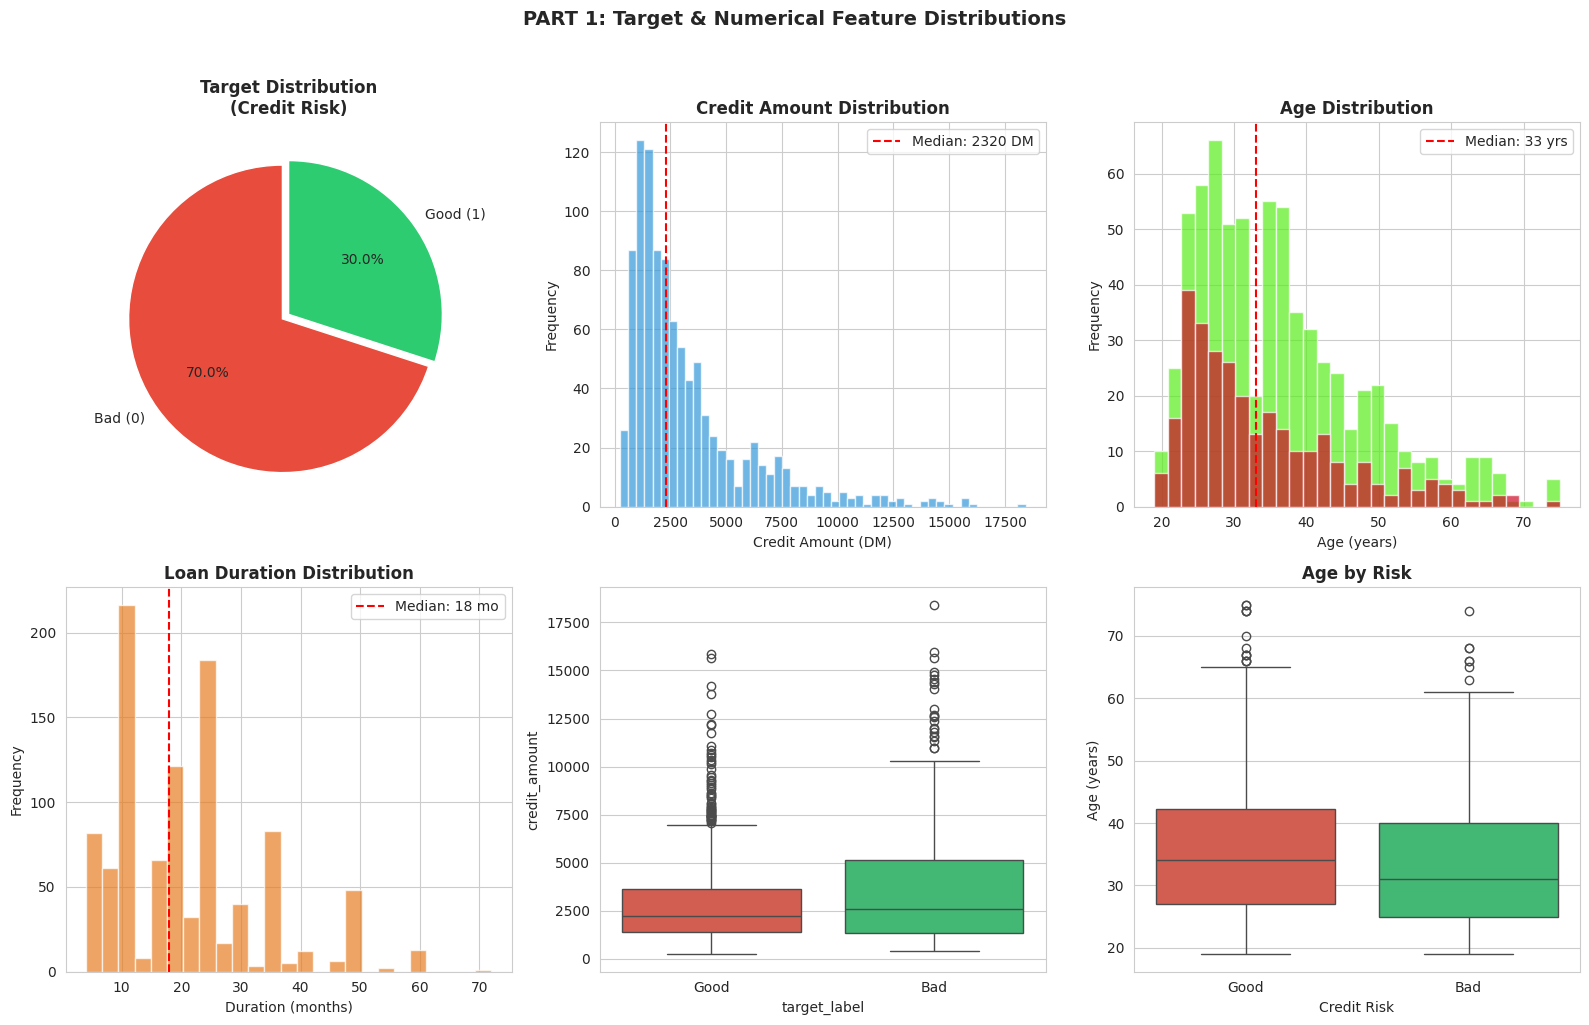

In [88]:
import seaborn as sns

sns.set_style("whitegrid")

df_clean['payment_to_income_ratio'] = df_clean['payment_to_income_ratio'].astype(int)
df_clean['residence_since'] = df_clean['residence_since'].astype(int)

fig3, axes3 = plt.subplots(2,3,figsize=(16,10))

# 1. Target Distribution

target_counts = df_clean['target'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes3[0, 0].pie(target_counts, labels=['Bad (0)', 'Good (1)'], autopct='%1.1f%%', 
               colors=colors, startangle=90, explode=(0.05, 0))
axes3[0, 0].set_title('Target Distribution\n(Credit Risk)', fontsize=12, fontweight='bold')

# 2. Credit Amount Distribution 
axes3[0, 1].hist(df_clean['credit_amount'], bins=50, color='#3498db', edgecolor='white', alpha=0.7)
axes3[0, 1].axvline(df_clean['credit_amount'].median(), color='red', linestyle='--', 
                   label=f'Median: {df_clean["credit_amount"].median():.0f} DM')
axes3[0, 1].set_title('Credit Amount Distribution', fontsize=12, fontweight='bold')
axes3[0, 1].set_xlabel('Credit Amount (DM)')
axes3[0, 1].set_ylabel('Frequency')
axes3[0, 1].legend()

# 3. Age Distribution

bins = np.histogram_bin_edges(df_clean['age'],bins=30)
axes3[0, 2].hist(df_clean[df_clean['target']==1]['age'], bins=bins, color="#5aed1b", edgecolor='white', alpha=0.7)
axes3[0, 2].hist(df_clean[df_clean['target']==0]['age'], bins=bins, color="#ce0d27", edgecolor='white', alpha=0.7)
axes3[0, 2].axvline(df_clean['age'].median(), color='red', linestyle='--', 
                   label=f'Median: {df_clean["age"].median():.0f} yrs')
axes3[0, 2].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes3[0, 2].set_xlabel('Age (years)')
axes3[0, 2].set_ylabel('Frequency')
axes3[0, 2].legend()

# 4. Loan duration distribution
axes3[1, 0].hist(df_clean['month_duration'], bins=25, color='#e67e22', edgecolor='white', alpha=0.7)
axes3[1, 0].axvline(df_clean['month_duration'].median(), color='red', linestyle='--', 
                   label=f'Median: {df_clean["month_duration"].median():.0f} mo')
axes3[1, 0].set_title('Loan Duration Distribution', fontsize=12, fontweight='bold')
axes3[1, 0].set_xlabel('Duration (months)')
axes3[1, 0].set_ylabel('Frequency')
axes3[1, 0].legend()

# 5. Credit amount by target (boxplot)
df_plot = df_clean.copy()
df_plot['target_label'] = df_plot['target'].map({0: 'Bad', 1: 'Good'})
sns.boxplot(data=df_plot, x='target_label', y='credit_amount', ax=axes3[1, 1], 
            palette=['#e74c3c', '#2ecc71'])
axes[1, 1].set_title('Credit Amount by Risk', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Credit Risk')
axes[1, 1].set_ylabel('Credit Amount (DM)')

# 6. Age by target (boxplot)
sns.boxplot(data=df_plot, x='target_label', y='age', ax=axes3[1, 2], 
            palette=['#e74c3c', '#2ecc71'])
axes3[1, 2].set_title('Age by Risk', fontsize=12, fontweight='bold')
axes3[1, 2].set_xlabel('Credit Risk')
axes3[1, 2].set_ylabel('Age (years)')

plt.suptitle('PART 1: Target & Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()



--- Key Correlation Insights ---
Correlation with target (strongest first):
  month_duration           : -0.215  (↓ lower risk)
  credit_amount            : -0.155  (↓ lower risk)
  age                      : +0.091  (↑ higher risk)
  payment_to_income_ratio  : -0.072  (↓ lower risk)
  n_credits                : +0.046  (↑ higher risk)
  n_guarantors             : +0.003  (↑ higher risk)
  residence_since          : -0.003  (↓ lower risk)


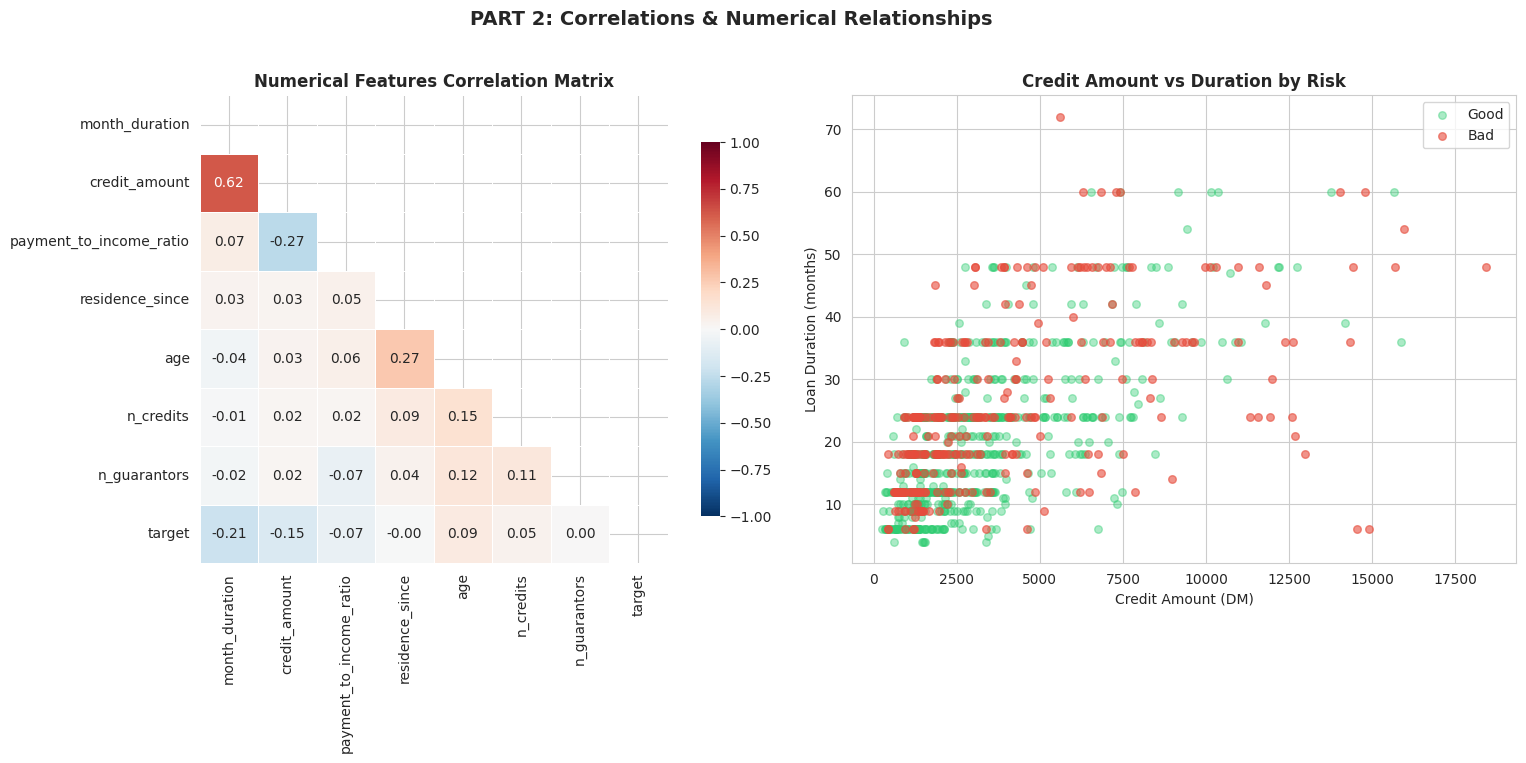

In [82]:

fig4, axes4 = plt.subplots(1, 2, figsize=(16, 7))

# 1. Correlation matrix of numerical features
numerical_cols = ['month_duration', 'credit_amount', 'payment_to_income_ratio', 
                  'residence_since', 'age', 'n_credits', 'n_guarantors', 'target']

corr_matrix = df_clean[numerical_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, ax=axes4[0], square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
axes4[0].set_title('Numerical Features Correlation Matrix', fontsize=12, fontweight='bold')

# 2. Pairplot-style scatter: key relationships
axes4[1].scatter(df_clean[df_clean['target']==1]['credit_amount'], df_clean[df_clean['target']==1]['month_duration'], 
                alpha=0.4, c='#2ecc71', label='Good', s=30)
axes4[1].scatter(df_clean[df_clean['target']==0]['credit_amount'], df_clean[df_clean['target']==0]['month_duration'], 
                alpha=0.6, c='#e74c3c', label='Bad', s=30)
axes4[1].set_xlabel('Credit Amount (DM)')
axes4[1].set_ylabel('Loan Duration (months)')
axes4[1].set_title('Credit Amount vs Duration by Risk', fontsize=12, fontweight='bold')
axes4[1].legend()

plt.suptitle('PART 2: Correlations & Numerical Relationships', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Print key correlation insights
print("\n--- Key Correlation Insights ---")
target_corr = corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)
print("Correlation with target (strongest first):")
for feat, corr in target_corr.items():
    direction = "↑ higher risk" if corr > 0 else "↓ lower risk"
    print(f"  {feat:25s}: {corr:+.3f}  ({direction})")


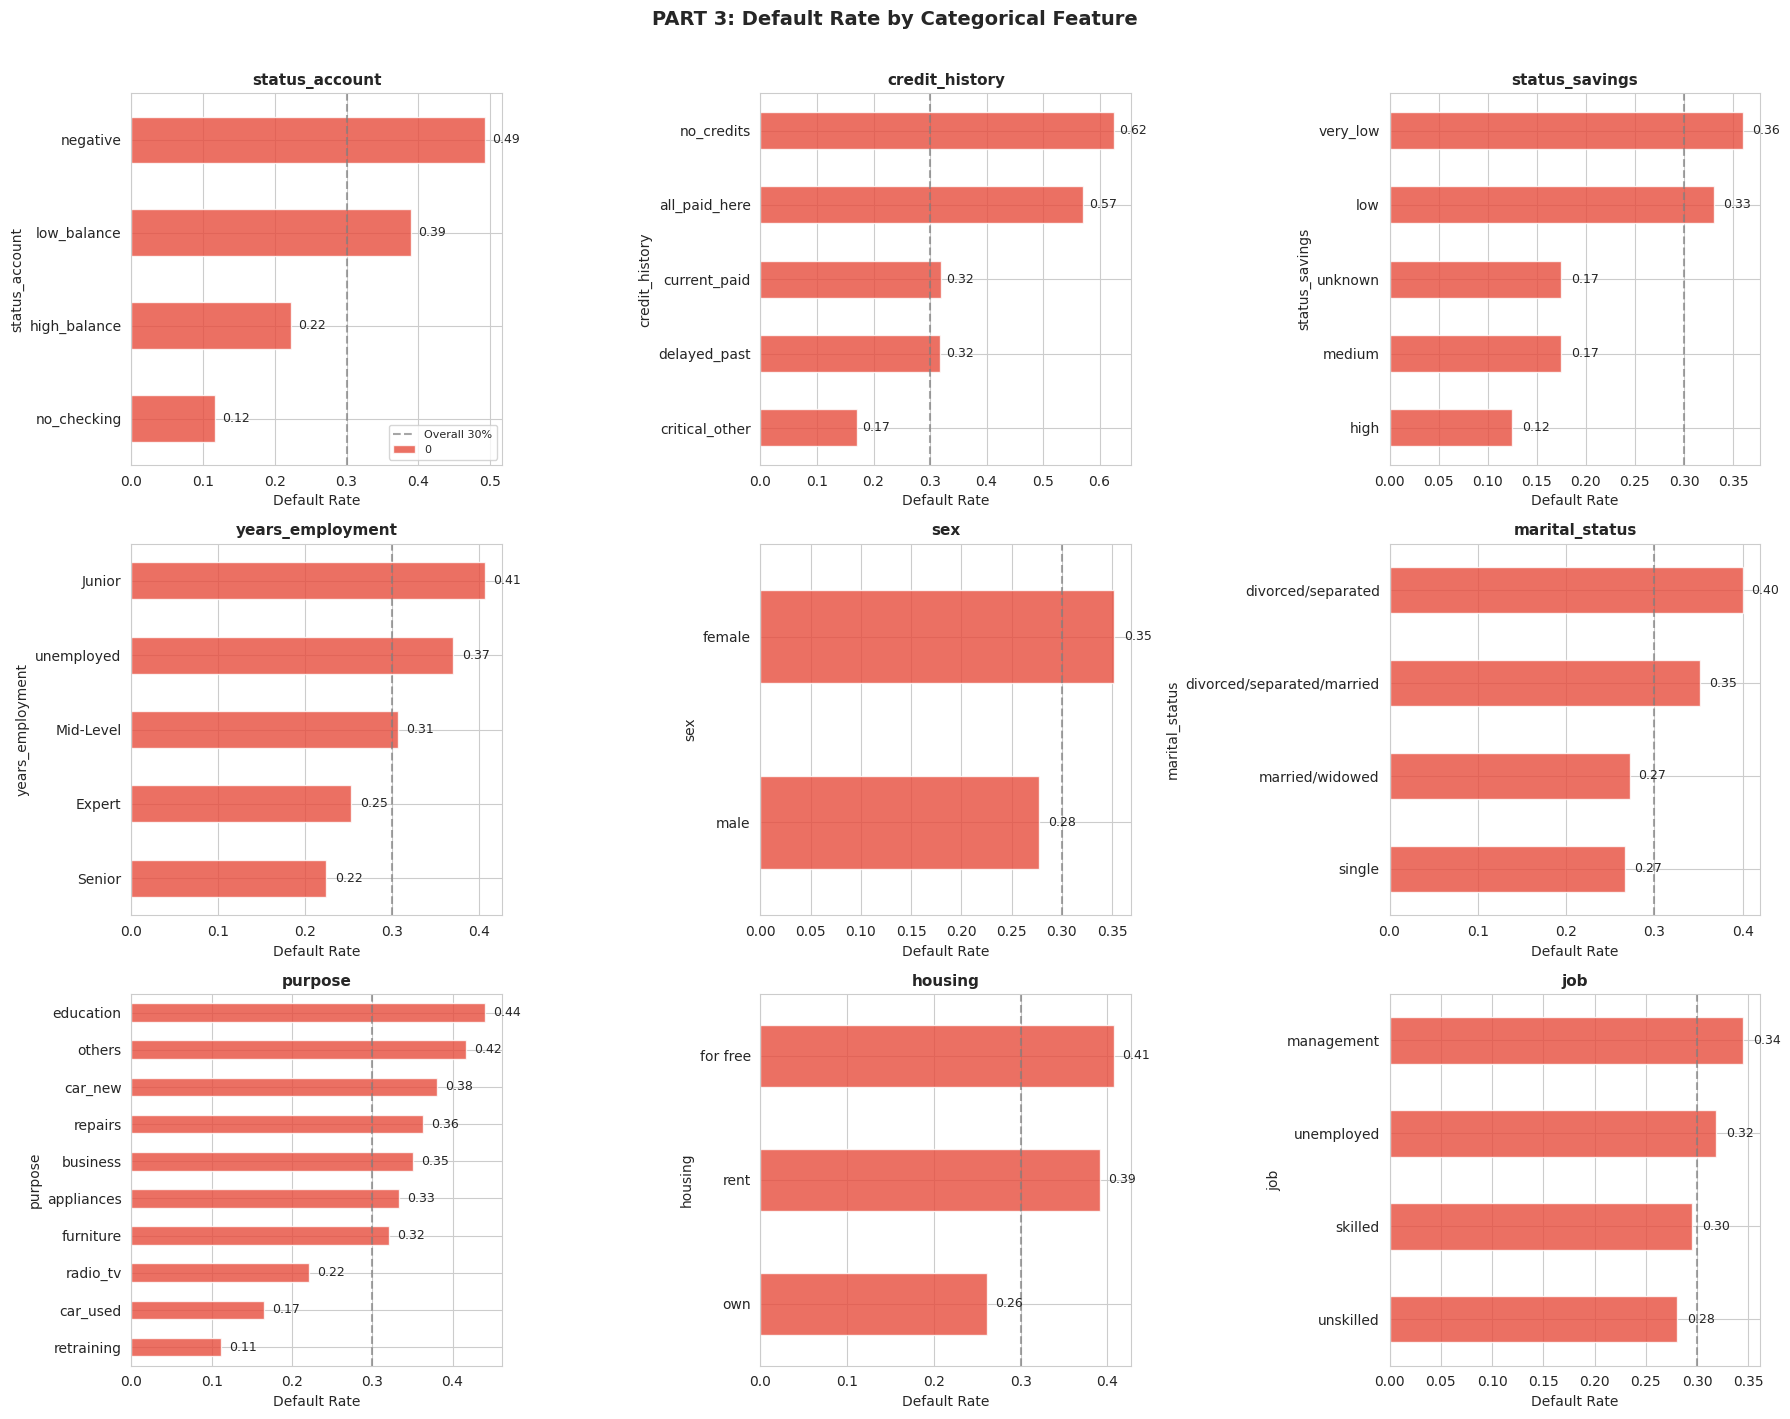

In [ ]:

fig5, axes5 = plt.subplots(3, 3, figsize=(18, 14))
axes5 = axes5.flatten()

categorical_features = ['status_account', 'credit_history', 'status_savings', 
                        'years_employment', 'sex', 'marital_status', 
                        'purpose', 'housing', 'job']

for idx, col in enumerate(categorical_features):

    # Calculate default rate by category
    crosstab = pd.crosstab(df_clean[col], df_clean['target'], normalize='index')
    crosstab = crosstab.sort_values(by=0, ascending=True)  # bad rate
    
    crosstab[0].plot(kind='barh', ax=axes5[idx], color='#e74c3c', alpha=0.8)
    axes5[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes5[idx].set_xlabel('Default Rate')
    axes5[idx].axvline(x=0.3, color='gray', linestyle='--', alpha=0.7, label='Overall 30%')
    
    # Add value labels
    for i, v in enumerate(crosstab[0]):
        axes5[idx].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
    
    if idx == 0:
        axes5[idx].legend(fontsize=8)

plt.suptitle('PART 3: Default Rate by Categorical Feature', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()



/tmp/ipykernel_4216/1684244138.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='target_label', y='log_credit_amount', ax=axes6[0, 0],


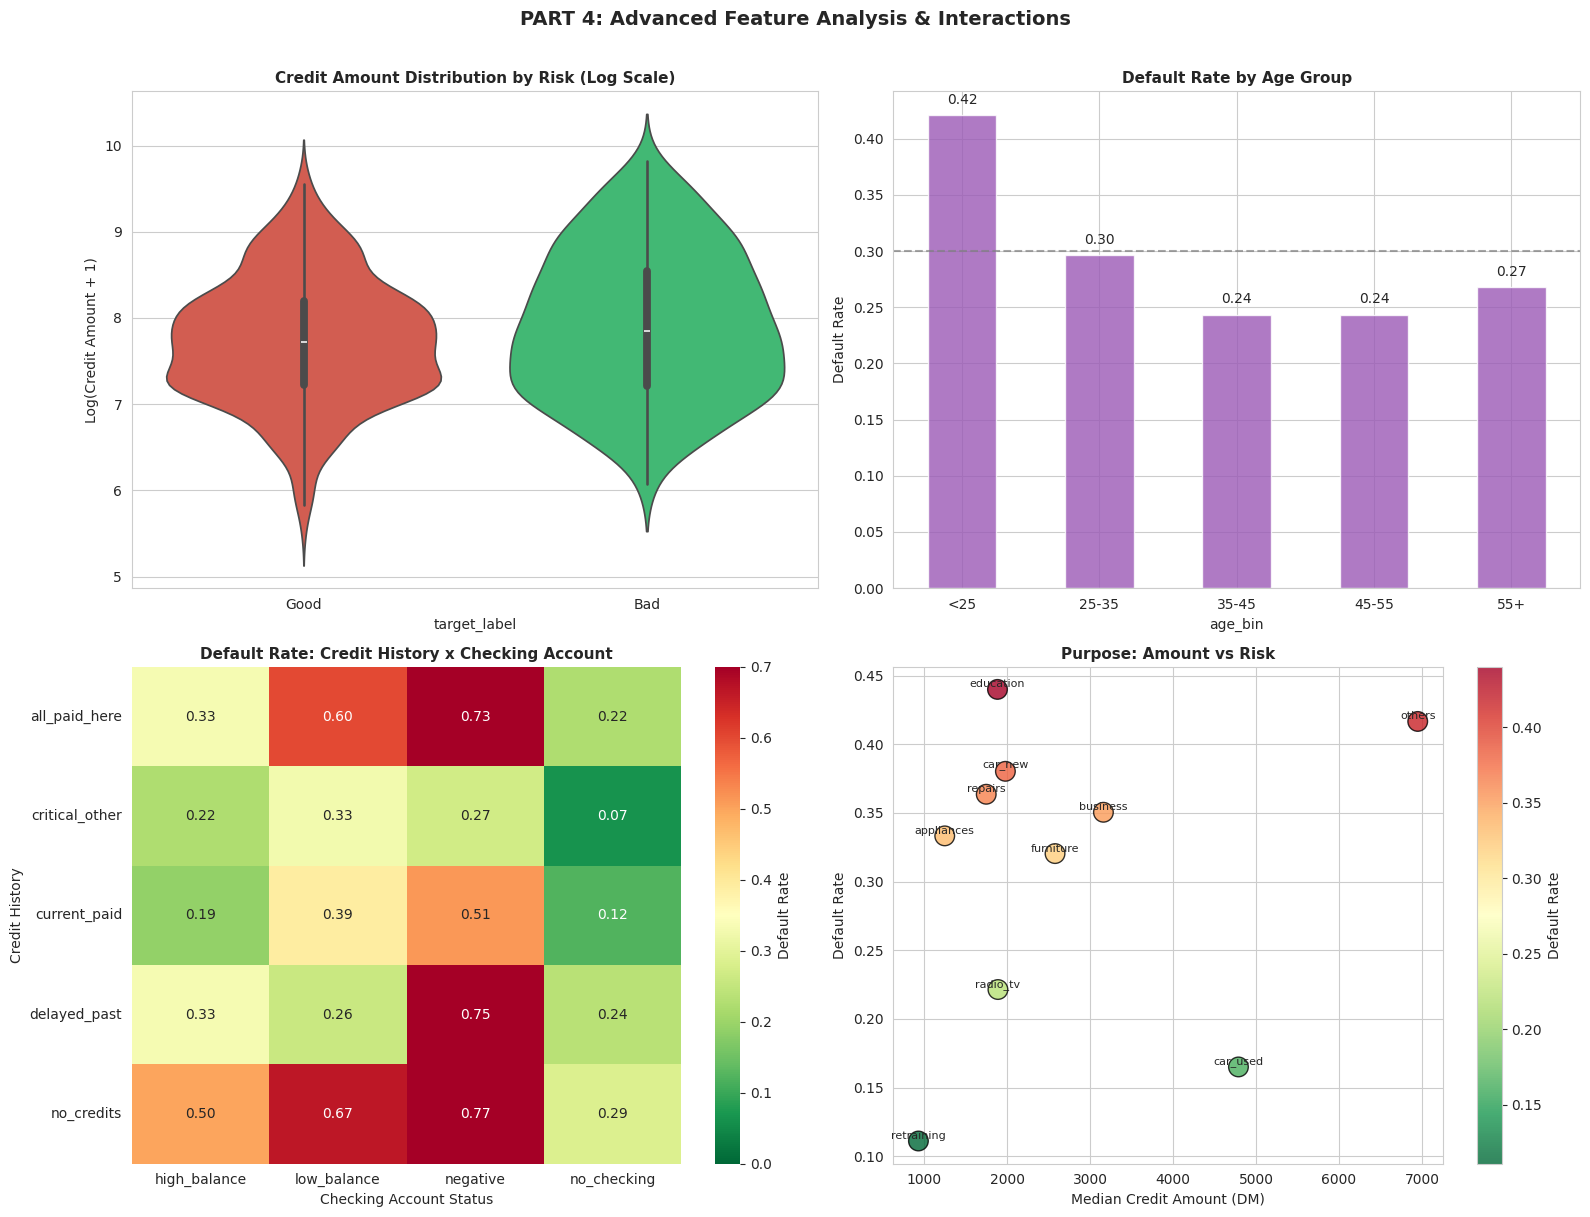

In [89]:


fig6, axes6 = plt.subplots(2, 2, figsize=(16, 12))

# 1. Credit Amount distribution by target (violin plot)

df_plot = df_clean.copy()
df_plot['target_label'] = df_plot['target'].map({0: 'Bad', 1: 'Good'})

# log scale for credit amount due to skewness
df_plot['log_credit_amount'] = np.log1p(df_plot['credit_amount'])
sns.violinplot(data=df_plot, x='target_label', y='log_credit_amount', ax=axes6[0, 0],
               palette=['#e74c3c', '#2ecc71'], inner='box')
axes6[0, 0].set_title('Credit Amount Distribution by Risk (Log Scale)', fontsize=11, fontweight='bold')
axes6[0, 0].set_ylabel('Log(Credit Amount + 1)')

# 2. Age bins vs default rate
df_plot['age_bin'] = pd.cut(df_plot['age'], bins=[0, 25, 35, 45, 55, 100], 
                            labels=['<25', '25-35', '35-45', '45-55', '55+'])
age_default = df_plot.groupby('age_bin')['target'].apply(lambda x: 1-x.mean())
age_default.plot(kind='bar', ax=axes6[0, 1], color='#9b59b6', alpha=0.8)
axes6[0, 1].set_title('Default Rate by Age Group', fontsize=11, fontweight='bold')
axes6[0, 1].set_ylabel('Default Rate')
axes6[0, 1].axhline(y=0.3, color='gray', linestyle='--', alpha=0.7)
axes6[0, 1].tick_params(axis='x', rotation=0)
for i, v in enumerate(age_default):
    axes6[0, 1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10)

# 3. Credit History + Checking Account interaction
interaction = df_clean.groupby(['credit_history', 'status_account'])['target'].apply(lambda x: 1 - x.mean()).unstack()
sns.heatmap(interaction, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes6[1, 0],
            vmin=0, vmax=0.7, cbar_kws={'label': 'Default Rate'})
axes6[1, 0].set_title('Default Rate: Credit History x Checking Account', fontsize=11, fontweight='bold')
axes6[1, 0].set_xlabel('Checking Account Status')
axes6[1, 0].set_ylabel('Credit History')

# 4. Loan purpose + amount interaction
purpose_stats = df_clean.groupby('purpose').agg({
    'credit_amount': 'median',
    'target': lambda x: 1 - x.mean()
}).reset_index()
purpose_stats = purpose_stats.sort_values('target', ascending=False)

scatter = axes6[1, 1].scatter(purpose_stats['credit_amount'], purpose_stats['target'], 
                              s=200, c=purpose_stats['target'], cmap='RdYlGn_r', 
                              edgecolors='black', linewidth=1, alpha=0.8)
axes6[1, 1].set_xlabel('Median Credit Amount (DM)')
axes6[1, 1].set_ylabel('Default Rate')
axes6[1, 1].set_title('Purpose: Amount vs Risk', fontsize=11, fontweight='bold')

# Add labels
for _, row in purpose_stats.iterrows():
    axes6[1, 1].annotate(row['purpose'], (row['credit_amount'], row['target']), 
                        fontsize=8, ha='center', va='bottom')

plt.colorbar(scatter, ax=axes6[1, 1], label='Default Rate')

plt.suptitle('PART 4: Advanced Feature Analysis & Interactions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

